# Tomato Leaf Detection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import all dependencies

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

# path link

In [ ]:
path = "/content/drive/MyDrive/disease/Plant_images/train/Grape___Black_rot"
os.listdir(path)

['valid', 'train']

# Join train and test with path

In [ ]:
train_path = os.path.join(path, "train")
print(os.listdir(train_path))
print("*"*100)
test_path = os.path.join(path, "")
print(os.listdir(test_path))

['1', '2']
****************************************************************************************************
['valid', 'train']


# glob function

In [ ]:
from glob import glob
folders = glob("/content/drive/MyDrive/disease/Plant_images/train/Grape___Black_rot")
folders

['/content/drive/MyDrive/disease/Plant_images/train/Grape___Black_rot']

Text(0.5, 1.0, 'Grape Black Rot')

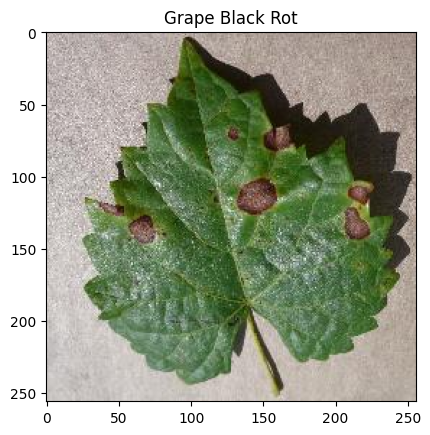

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(plt.imread("/content/drive/MyDrive/disease/Plant_images/train/Grape___Black_rot/train/1/5ad6fd71-d78a-4f4c-b195-1b0a69ae0de3___FAM_B.Rot 3433.JPG"))
plt.title("Grape Black Rot")

Text(0.5, 1.0, 'Grape Rot Flip')

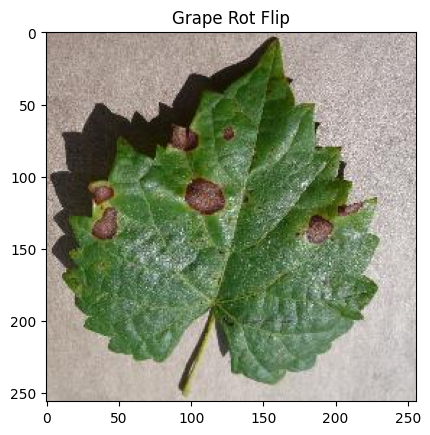

In [ ]:
plt.imshow(plt.imread("/content/drive/MyDrive/disease/Plant_images/train/Grape___Black_rot/train/1/5ad6fd71-d78a-4f4c-b195-1b0a69ae0de3___FAM_B.Rot 3433_flipLR.JPG"))
plt.title("Grape Rot Flip")

Text(0.5, 1.0, 'Grape Rot 2')

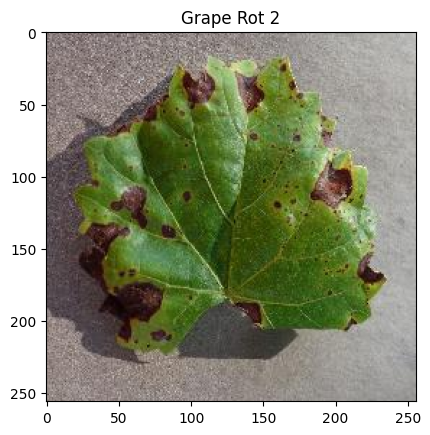

In [ ]:
plt.imshow(plt.imread("/content/drive/MyDrive/disease/Plant_images/train/Grape___Black_rot/train/1/5c237a28-eeef-4cc6-a6c5-f9360022dd3e___FAM_B.Rot 5081.JPG"))
plt.title("Grape Rot 2")

# import necessary packages

In [ ]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential

# image size

In [ ]:
SIZE = [128, 128]

# import VGG19

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg19 import VGG19

# vgg19 with input shape and weight is imagenet

In [ ]:
vg19 = VGG19(input_shape=SIZE + [3], weights="imagenet", include_top=False)

In [ ]:
for layer in vg19.layers:
    layer.trainable = False

In [ ]:
x = Flatten()(vg19.output)

In [ ]:
prediction = Dense(len(folders), activation="softmax")(x)

modelvg = Model(inputs=vg19.input, outputs=prediction)

# VGG19 model summary

In [ ]:
modelvg.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0   

# Compile model

In [ ]:
modelvg.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer="adam")

# Data Augmentation

In [ ]:
train_datagen_vg19 = ImageDataGenerator(rescale=1./255)

test_datagen_vg19 = ImageDataGenerator(rescale=1./255)

In [ ]:
trainning_set_vg19 = train_datagen_vg19.flow_from_directory(train_path,
                                                 target_size=(128, 128),
                                                 batch_size=16,
                                                 class_mode="categorical", shuffle=True)

Found 889 images belonging to 2 classes.


In [ ]:
testing_set_vg19 = test_datagen_vg19.flow_from_directory(test_path,
                                                 target_size=(128, 128),
                                                 batch_size=16,
                                                 class_mode="categorical", shuffle=False)

Found 1897 images belonging to 2 classes.


# model fit_genrator

In [ ]:
import tensorflow as tf

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

r_vg19 = modelvg.fit_generator(trainning_set_vg19,
                       validation_data=testing_set_vg19,
                       epochs=2,
                       callbacks=[callback]
                       )

# Visualization for VGG19

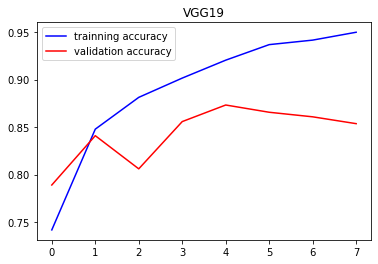

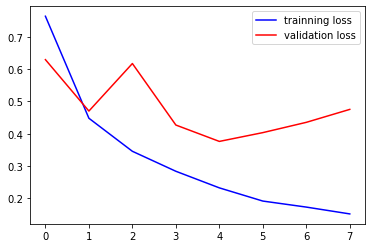

In [ ]:
import matplotlib.pyplot as plt
accuracy = r_vg19.history['accuracy']
val_accuracy = r_vg19.history['val_accuracy']
loss = r_vg19.history['loss']
val_loss = r_vg19.history['val_loss']
epochs = range(len(accuracy))
plt.title("VGG19")
plt.plot(epochs, accuracy, "b", label="trainning accuracy")
plt.plot(epochs, val_accuracy, "r", label="validation accuracy")
plt.legend()
plt.show()

plt.plot(epochs, loss, "b", label="trainning loss")
plt.plot(epochs, val_loss, "r", label="validation loss")
plt.legend()
plt.show()

In [ ]:
y_pred = modelvg.predict(testing_set_vg19)

In [ ]:
y_pred

array([[9.5760453e-01, 1.0417310e-02, 7.9893187e-05, ..., 3.0077353e-02,
        5.5765063e-11, 1.0953667e-10],
       [9.9386579e-01, 6.0801003e-03, 4.2962211e-06, ..., 4.8831708e-07,
        1.6056711e-14, 2.8610159e-10],
       [9.9571407e-01, 3.4797029e-03, 1.6067212e-04, ..., 4.9429218e-04,
        2.9090335e-09, 2.2183949e-07],
       ...,
       [4.7132817e-05, 5.9945545e-05, 9.0311325e-05, ..., 2.1704422e-05,
        7.0140032e-08, 9.9763250e-01],
       [3.5790534e-05, 4.8716959e-07, 2.5694172e-07, ..., 8.9223839e-08,
        4.1584966e-10, 9.9994385e-01],
       [7.7850677e-11, 3.0743747e-04, 1.0938089e-07, ..., 2.8351431e-08,
        6.2542938e-08, 9.9924636e-01]], dtype=float32)

In [ ]:
y_pred = np.argmax(y_pred, axis=1)
y_pred

array([0, 0, 0, ..., 9, 9, 9])

# Tomato Bacterial Spot

In [ ]:
test_img = plt.imread("../input/tomato/New Plant Diseases Dataset(Augmented)/train/Tomato___Bacterial_spot/00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_Bact.Sp 3110.JPG")

# Visualize

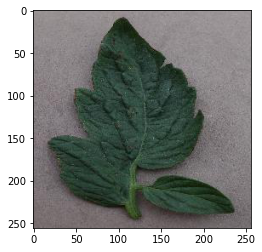

In [ ]:
plt.imshow(test_img)

# Save model

In [ ]:
modelvg.save("vgg_19tl.model")

# load a image and detection

In [ ]:
import cv2
import tensorflow as tf
def prepare(filepath):
    img_array = cv2.imread(filepath, cv2.IMREAD_COLOR)
    img_array = img_array / 255
    new_array = cv2.resize(img_array, (128, 128))
    return new_array.reshape(-1, 128, 128, 3)

model = tf.keras.models.load_model("vgg_19tl.model")

# prediction

# Class Dictionary

In [ ]:
class_dict = trainning_set_vg19.class_indices
class_dict

{'Tomato___Bacterial_spot': 0,
 'Tomato___Early_blight': 1,
 'Tomato___Late_blight': 2,
 'Tomato___Leaf_Mold': 3,
 'Tomato___Septoria_leaf_spot': 4,
 'Tomato___Spider_mites Two-spotted_spider_mite': 5,
 'Tomato___Target_Spot': 6,
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7,
 'Tomato___Tomato_mosaic_virus': 8,
 'Tomato___healthy': 9}

# label

In [ ]:
def prediction_cls(prediction):
    for key, clss in class_dict.items():
        if np.argmax(prediction) == clss:
            return key

In [ ]:
prediction = model.predict([prepare("../input/tomato/New Plant Diseases Dataset(Augmented)/valid/Tomato___healthy/0a334ae6-bea3-4453-b200-85e082794d56___GH_HL Leaf 310.1_flipTB.JPG")])
prediction_cls(prediction)

'Tomato___healthy'

In [ ]:
prediction = model.predict([prepare("../input/tomato/New Plant Diseases Dataset(Augmented)/valid/Tomato___Tomato_Yellow_Leaf_Curl_Virus/101849ce-d61a-4c2f-a6a7-8da0d71f237e___YLCV_NREC 2725.JPG")])

prediction_cls(prediction)

'Tomato___Tomato_Yellow_Leaf_Curl_Virus'